# K-Nearest Neighbors

            ## 1. Learning objectives

            - Calculate Euclidean and Manhattan distance
- Implement neighbor voting
- Explain scaling and the curse of dimensionality

            ## 2. Prerequisites

            Basic Python, NumPy arrays, means, and the supervised-learning overview.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")

Python lesson ready; reproducible seed = 42


## 3. Problem definition

            Predict from the labels of the most similar stored training observations.

            ## 4. Real-world use cases

            - Risk classification
- Demand prediction
- Decision-support ranking

            ## 5. Core intuition in simple language

            Find nearby examples and let them vote; small k follows local detail while large k smooths broadly.

## 6. Mathematical foundation

            $$d_2(\mathbf x,\mathbf z)=\sqrt{\sum_{j=1}^{p}(x_j-z_j)^2},\qquad d_1(\mathbf x,\mathbf z)=\sum_{j=1}^{p}|x_j-z_j|.$$

            **Every symbol:**

            - $d_2$ is Euclidean distance.
- $d_1$ is Manhattan distance.
- $\mathbf x,\mathbf z$ are feature vectors.
- $p$ is feature count.
- $j$ indexes features.

            **Why the equation is needed:** Nearest-neighbor predictions require a precise definition of similarity.

            **Small numerical example:** Between (0,0) and (3,4), Euclidean distance is 5 and Manhattan distance is 7.

            **Connection to Python:** np.sqrt(np.sum((X-row)**2,axis=1)) and np.sum(np.abs(X-row),axis=1) implement the metrics.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Define target and success metric
2. Split observations before fitted preprocessing
3. Build a simple baseline
4. Fit a transparent implementation
5. Fit the library estimator
6. Tune with validation evidence
7. Evaluate once on untouched test data

## 9. Implementation from scratch

A readable NumPy version exposes the mechanism and is checked against a tiny hand calculation.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
class KNNScratch:
    def __init__(self,k=5,metric="euclidean"):
        self.k=k; self.metric=metric
    def fit(self,features,target):
        self.features_=np.asarray(features); self.target_=np.asarray(target); return self
    def _distance(self,row):
        difference=np.abs(self.features_-row)
        return np.sqrt(np.sum(difference**2,axis=1)) if self.metric=="euclidean" else np.sum(difference,axis=1)
    def predict(self,features):
        predictions=[]
        for row in features:
            nearest=np.argsort(self._distance(row))[:self.k]
            labels,counts=np.unique(self.target_[nearest],return_counts=True)
            predictions.append(labels[np.argmax(counts)])
        return np.asarray(predictions)

print("Euclidean/Manhattan:",np.sqrt((3-0)**2+(4-0)**2),abs(3)+abs(4))

Euclidean/Manhattan: 5.0 7


## 10. Implementation using a standard library

Scikit-learn adds efficient numerical routines, validation, pipelines, and model-selection compatibility.

## 11. Dataset loading and exploration

The lesson uses a bundled or generated scikit-learn dataset with a fixed seed and no network access.

## 12. Data preprocessing

Train/validation/test roles are separated before scaling or other fitted transformations to prevent data leakage.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Scratch/library accuracy: 0.8888888888888888 0.8888888888888888


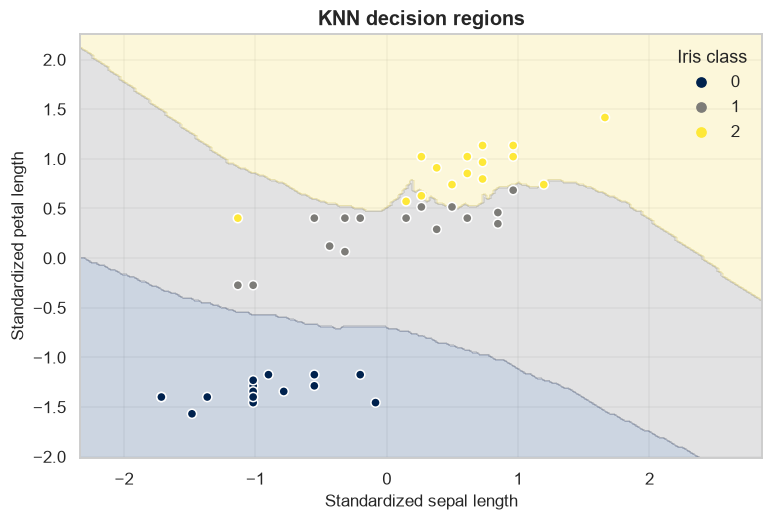

In [3]:
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

iris=load_iris()
X=iris.data[:,[0,2]]; y=iris.target
X_train,X_validation,y_train,y_validation=train_test_split(X,y,test_size=.3,stratify=y,random_state=RANDOM_SEED)
scaler=StandardScaler(); X_train_s=scaler.fit_transform(X_train); X_validation_s=scaler.transform(X_validation)
scratch=KNNScratch(k=5).fit(X_train_s,y_train)
library=KNeighborsClassifier(n_neighbors=5).fit(X_train_s,y_train)
scratch_prediction=scratch.predict(X_validation_s); library_prediction=library.predict(X_validation_s)
print("Scratch/library accuracy:",accuracy_score(y_validation,scratch_prediction),accuracy_score(y_validation,library_prediction))

x_grid=np.linspace(X_train_s[:,0].min()-.5,X_train_s[:,0].max()+.5,180)
y_grid=np.linspace(X_train_s[:,1].min()-.5,X_train_s[:,1].max()+.5,180)
xx,yy=np.meshgrid(x_grid,y_grid); grid=np.c_[xx.ravel(),yy.ravel()]
regions=library.predict(grid).reshape(xx.shape)
figure,axis=plt.subplots(); axis.contourf(xx,yy,regions,alpha=.2,cmap="cividis"); scatter=axis.scatter(X_validation_s[:,0],X_validation_s[:,1],c=y_validation,cmap="cividis",edgecolor="white",label="Validation observations")
axis.set(title="KNN decision regions",xlabel="Standardized sepal length",ylabel="Standardized petal length"); axis.legend(*scatter.legend_elements(),title="Iris class"); plt.show()

**How to interpret the result:** Regions show local voting. Scaling is essential because a large-unit feature would otherwise dominate every distance.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Small k has low bias and high variance; large k has higher bias and lower variance. Validation selects the compromise.

,k,train_accuracy,validation_accuracy
0,1,0.990,0.889
1,3,0.971,0.911
2,5,0.971,0.889
3,7,0.962,0.911
4,9,0.962,0.933
5,11,0.962,0.956
6,13,0.924,0.933
7,15,0.914,0.911
8,17,0.886,0.956
9,19,0.876,0.933


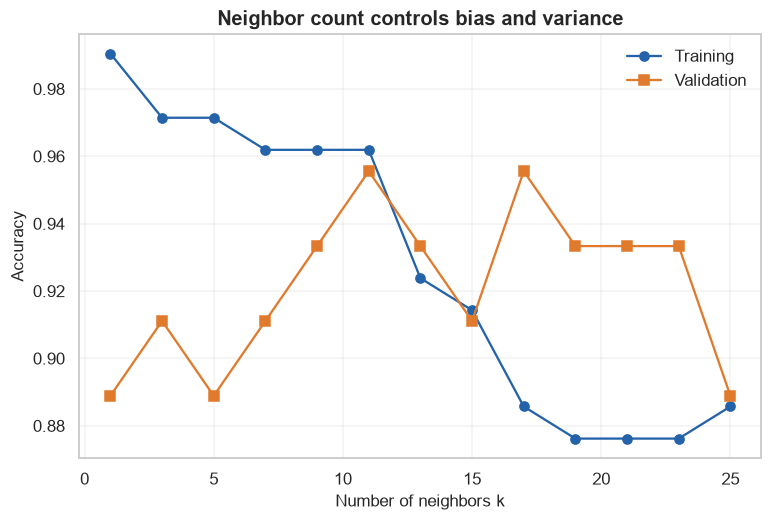

In [4]:
rows=[]
for k in range(1,26,2):
    candidate=KNeighborsClassifier(n_neighbors=k).fit(X_train_s,y_train)
    rows.append({"k":k,"train_accuracy":candidate.score(X_train_s,y_train),"validation_accuracy":candidate.score(X_validation_s,y_validation)})
results=pd.DataFrame(rows); display(results.round(3))
figure,axis=plt.subplots(); axis.plot(results["k"],results["train_accuracy"],marker="o",label="Training",color=COURSE_COLORS["blue"]); axis.plot(results["k"],results["validation_accuracy"],marker="s",label="Validation",color=COURSE_COLORS["orange"])
axis.set(title="Neighbor count controls bias and variance",xlabel="Number of neighbors k",ylabel="Accuracy"); axis.legend(); plt.show()

## 18. Common mistakes

            - Fitting preprocessing before splitting
- Selecting hyperparameters on test data
- Reporting one metric without a baseline
- Confusing predictive association with causation

            ## 19. Advantages and disadvantages

            **Advantages**

            - Direct objective from labeled examples
- Clear held-out evaluation

            **Disadvantages**

            - Prediction can be slow and memory-heavy
- Distances become less informative as dimensionality grows
- Sensitive to scaling and irrelevant features

            ## 20. When to use and when not to use the algorithm

            **Use it when:** a trustworthy target represents the decision and representative labeled examples are available.

            **Do not use it when:** labels do not represent the desired outcome or the goal is causal intervention rather than prediction.

## 21. Exercises

1. **Conceptual:** Why must the test set remain untouched during selection?
2. **Mathematical/hand calculation:** Calculate the displayed equation on a small example.
3. **Coding/experimentation:** Change one hyperparameter and explain training-versus-validation behavior.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Repeated test feedback leaks selection information and makes final performance optimistic.
2. Substitute each number, compute in the displayed order, and retain units.
3. Keep the split fixed, retrain each candidate, and prefer stable validation evidence rather than the best training score.

</details>

## 23. Summary and key takeaways

            - Data splitting and preprocessing are part of the model
- Scratch code explains the mechanism while the library version supports realistic use
- Metrics must match error costs
- Generalization—not memorization—is the objective

            ## 24. Further reading

            - [scikit-learn supervised learning guide](https://scikit-learn.org/stable/supervised_learning.html)
- [scikit-learn common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html)